In [1]:
!pip -q install pymupdf wordcloud pandas matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.9/24.9 MB 25.1 MB/s eta 0:00:00


In [2]:
from google.colab import files

print("Sube tus PDFs:")
uploaded = files.upload()

Sube tus PDFs:


Saving 2404.00806v5.pdf to 2404.00806v5.pdf
Saving 2404.15158v4.pdf to 2404.15158v4.pdf
Saving 2507.12673v3.pdf to 2507.12673v3.pdf
Saving 2508.12860v2.pdf to 2508.12860v2.pdf
Saving 2509.24508v2.pdf to 2509.24508v2.pdf
Saving 2603.05563v1.pdf to 2603.05563v1.pdf
Saving 2603.05660v1.pdf to 2603.05660v1.pdf
Saving 2603.06098v1.pdf to 2603.06098v1.pdf
Saving 2603.06106v1.pdf to 2603.06106v1.pdf
Saving 2603.06118v1.pdf to 2603.06118v1.pdf


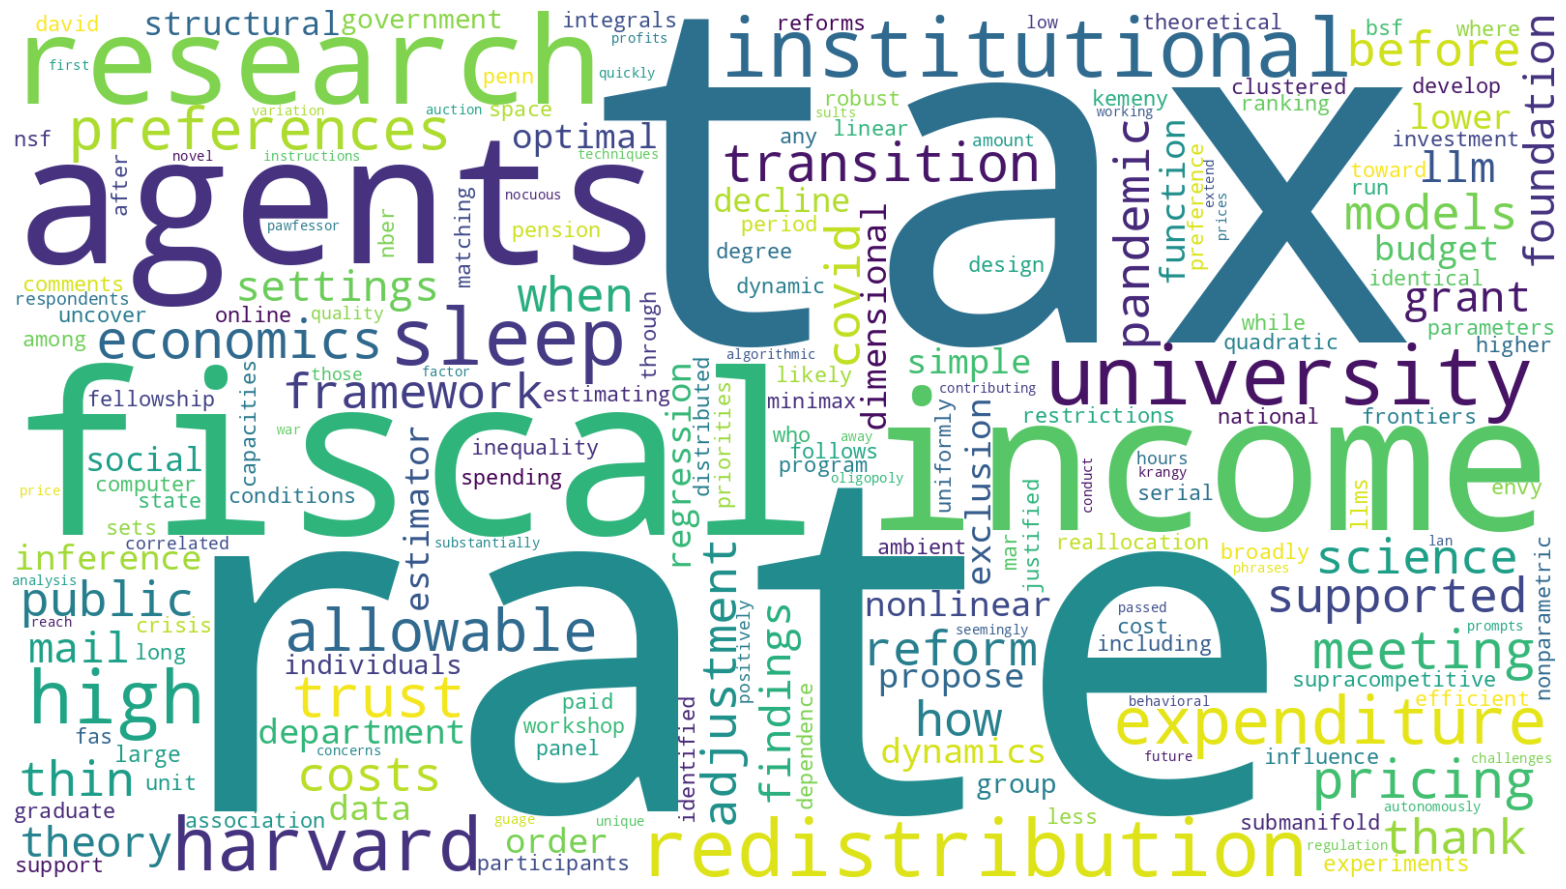

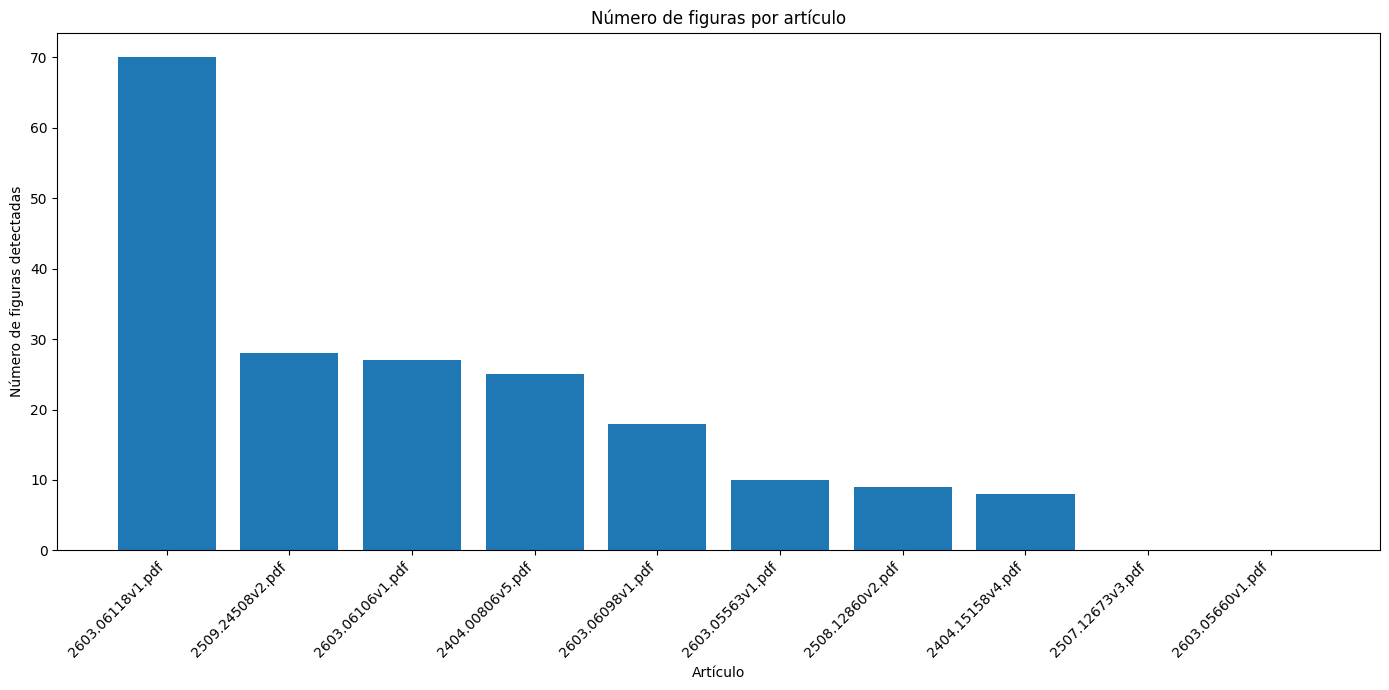


Archivos generados en /outputs:
- outputs/article_links.csv
- outputs/figures_per_article.png
- outputs/keyword_cloud.png
- outputs/paper_summary.csv
- outputs/validation_samples.csv


In [3]:
import os
import re
import math
import json
import logging
from pathlib import Path
from collections import Counter, defaultdict

import fitz
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud


# Configuración

# ubicación pdf
PDF_DIR = Path(".")
# crea carpeta para resultados
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

# configura sistema logs
logging.basicConfig(
    level=logging.INFO,
    format="%(levelname)s - %(message)s"
)

# filtro de palabras para evitar en la nube (no muy interesantes)
STOPWORDS = {
    "the", "and", "of", "to", "in", "a", "for", "is", "that", "we", "with", "this",
    "on", "as", "are", "by", "an", "be", "our", "from", "can", "these", "at", "or",
    "their", "using", "show", "shows", "paper", "study", "results", "result", "also",
    "into", "than", "such", "more", "may", "not", "have", "has", "had", "was", "were",
    "it", "its", "they", "them", "which", "but", "been", "than", "than", "via", "over",
    "used", "use", "based", "between", "across", "within", "there", "here", "new",
    "one", "two", "three", "using", "provide", "provides", "abstract", "find", "finds", "found"
}

# expresión para encontrar urls
URL_REGEX = re.compile(
    r"(https?://[^\s<>\)\]]+|www\.[^\s<>\)\]]+|doi\.org/[^\s<>\)\]]+)",
    re.IGNORECASE
)

# FUNCIONES AUXILIARES

# limpia espacios redundantes
def normalize_spaces(text: str) -> str:
    return re.sub(r"\s+", " ", text).strip()

# obtiene los pdf
def get_pdf_files(pdf_dir: Path):
    pdfs = sorted(pdf_dir.glob("*.pdf"))
    if not pdfs:
        raise FileNotFoundError("No se encontraron PDFs en el directorio actual.")
    return pdfs

# saca texto de cada página
def extract_text_by_page(doc):
    pages = []
    for page in doc:
        try:
            text = page.get_text("text")
        except Exception:
            text = ""
        pages.append(text or "")
    return pages

# saca todos los links
def extract_links(doc, pages_text):
    links = set()

    # 1) embedded links
    for page_num in range(len(doc)):
        try:
            page_links = doc[page_num].get_links()
            for link in page_links:
                uri = link.get("uri")
                if uri:
                    links.add(uri.strip())
        except Exception:
            pass

    # links detectados por regex
    for text in pages_text:
        for match in URL_REGEX.findall(text):
            clean = match.strip(".,);:]}>\"'")
            if clean.startswith("www."):
                clean = "http://" + clean
            links.add(clean)

    return sorted(links)

# detecta patrones como Figure 1, Fig. 2, FIGURE 3
def count_figures_from_text(pages_text):
    figure_pattern = re.compile(r"\b(?:Figure|Fig\.?)\s*\d+\b", re.IGNORECASE)
    count = 0
    for text in pages_text:
        count += len(figure_pattern.findall(text))
    return count

# saca el título
def extract_title(doc, filename):
    meta_title = (doc.metadata or {}).get("title", "")
    if meta_title and len(meta_title.strip()) > 5:
        return normalize_spaces(meta_title)

    # primeras líneas de la primera página
    first_page = doc[0].get_text("text")
    lines = [normalize_spaces(line) for line in first_page.splitlines() if line.strip()]
    candidate_lines = []
    for line in lines[:12]:
        if len(line) > 8 and not re.search(r"abstract|arxiv|keywords|jel|introduction", line, re.I):
            candidate_lines.append(line)
    if candidate_lines:
        return candidate_lines[0]
    return filename

# busca "Abstract" y corta antes de "Introduction" o algún equivalente
def extract_abstract_from_text(pages_text):
    first_pages_text = "\n".join(pages_text[:3])

    abstract_match = re.search(
        r"\bAbstract\b[:\s]*",
        first_pages_text,
        flags=re.IGNORECASE
    )
    if not abstract_match:
        return ""

    start = abstract_match.end()

    # patrones del abstract
    end_patterns = [
        r"\b1\s+Introduction\b",
        r"\bIntroduction\b",
        r"\bKeywords\b",
        r"\bJEL\b",
        r"\b1\.\s+Introduction\b"
    ]

    ends = []
    remaining = first_pages_text[start:]
    for pat in end_patterns:
        m = re.search(pat, remaining, flags=re.IGNORECASE)
        if m:
            ends.append(m.start())

    if ends:
        end = min(ends)
        abstract = remaining[:end]
    else:
        abstract = remaining[:2500]

    abstract = normalize_spaces(abstract)
    return abstract

# convierte texto en tokens
def tokenize(text):
    text = text.lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    tokens = [t for t in text.split() if len(t) > 2 and t not in STOPWORDS]
    return tokens


# Proceso principal

pdf_files = get_pdf_files(PDF_DIR)
logging.info(f"Se encontraron {len(pdf_files)} PDFs.")

records = []
all_abstract_tokens = []
validation_rows = []

for pdf_path in pdf_files:
    logging.info(f"Procesando: {pdf_path.name}")
    try:
        doc = fitz.open(pdf_path)
        pages_text = extract_text_by_page(doc)

        title = extract_title(doc, pdf_path.name)
        abstract = extract_abstract_from_text(pages_text)
        figure_count = count_figures_from_text(pages_text)
        links = extract_links(doc, pages_text)

        tokens = tokenize(abstract)
        all_abstract_tokens.extend(tokens)

        records.append({
            "filename": pdf_path.name,
            "title": title,
            "abstract": abstract,
            "abstract_word_count": len(tokens),
            "figure_count": figure_count,
            "link_count": len(links),
            "links": " | ".join(links)
        })

        validation_rows.append({
            "filename": pdf_path.name,
            "title": title,
            "abstract_extracted_preview": abstract[:400],
            "figure_count_detected": figure_count,
            "first_5_links": " | ".join(links[:5])
        })

        doc.close()

    except Exception as e:
        logging.error(f"Error procesando {pdf_path.name}: {e}")

df = pd.DataFrame(records)
validation_df = pd.DataFrame(validation_rows)

# Guarda tabla resumen y muestras
summary_csv = OUTPUT_DIR / "paper_summary.csv"
df.to_csv(summary_csv, index=False)

validation_csv = OUTPUT_DIR / "validation_samples.csv"
validation_df.to_csv(validation_csv, index=False)


# CSV de links

link_rows = []
for _, row in df.iterrows():
    raw_links = row["links"].split(" | ") if row["links"] else []
    if raw_links == [""]:
        raw_links = []
    if not raw_links:
        link_rows.append({
            "filename": row["filename"],
            "title": row["title"],
            "link": ""
        })
    else:
        for link in raw_links:
            link_rows.append({
                "filename": row["filename"],
                "title": row["title"],
                "link": link
            })

links_df = pd.DataFrame(link_rows)
links_csv = OUTPUT_DIR / "article_links.csv"
links_df.to_csv(links_csv, index=False)


# Nube de palabras

if all_abstract_tokens:
    freq = Counter(all_abstract_tokens)
    wc = WordCloud(width=1600, height=900, background_color="white")
    wc.generate_from_frequencies(freq)

    plt.figure(figsize=(16, 9))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.tight_layout()
    wc_path = OUTPUT_DIR / "keyword_cloud.png"
    plt.savefig(wc_path, dpi=200, bbox_inches="tight")
    plt.show()
else:
    logging.warning("No se pudieron extraer abstracts suficientes para la nube de palabras.")


# Gráfico de figuras

if not df.empty:
    plot_df = df.sort_values("figure_count", ascending=False)

    plt.figure(figsize=(14, 7))
    plt.bar(plot_df["filename"], plot_df["figure_count"])
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Número de figuras detectadas")
    plt.xlabel("Artículo")
    plt.title("Número de figuras por artículo")
    plt.tight_layout()

    fig_plot_path = OUTPUT_DIR / "figures_per_article.png"
    plt.savefig(fig_plot_path, dpi=200, bbox_inches="tight")
    plt.show()

print("\nArchivos generados en /outputs:")
for p in sorted(OUTPUT_DIR.glob("*")):
    print("-", p)

In [4]:
import pandas as pd

summary = pd.read_csv("outputs/paper_summary.csv")
validation = pd.read_csv("outputs/validation_samples.csv")

print("Resumen:")
display(summary[["filename", "title", "abstract_word_count", "figure_count", "link_count"]])

print("\nMuestra para validación manual:")
display(validation)

Resumen:


,filename,title,abstract_word_count,figure_count,link_count
0,2404.00806v5.pdf,Algorithmic Collusion by Large Language Models,269,25,28
1,2404.15158v4.pdf,On the Monotonicity of Information Costs,40,8,8
2,2507.12673v3.pdf,Thin Sets Are Not Equally Thin: Minimax Learni...,88,0,1
3,2508.12860v2.pdf,Estimation and exclusion restrictions in clust...,73,9,1
4,2509.24508v2.pdf,Identifying the post-pandemic determinants of ...,0,28,10
5,2603.05563v1.pdf,Nonlinear Fiscal Transitions and the Dynamics ...,167,10,1
6,2603.05660v1.pdf,Making Serial Dictatorships Fair,66,0,2
7,2603.06098v1.pdf,The Widening Gap in Tax Attitudes: Role of Gov...,65,18,4
8,2603.06106v1.pdf,Preference for redistribution and institutiona...,60,27,6
9,2603.06118v1.pdf,Sleep and redistribution preferences: Considering,103,70,44



Muestra para validación manual:


,filename,title,abstract_extracted_preview,figure_count_detected,first_5_links
0,2404.00806v5.pdf,Algorithmic Collusion by Large Language Models,We conduct experiments with algorithmic pricin...,25,http://arxiv.org/abs/2303.08774 | http://www.c...
1,2404.15158v4.pdf,On the Monotonicity of Information Costs,We study the monotonicity of information costs...,8,http://dx.doi.org/10.1016/j.jet.2023.105679 | ...
2,2507.12673v3.pdf,Thin Sets Are Not Equally Thin: Minimax Learni...,Many economic parameters are identified by “th...,0,https://arxiv.org/abs/2507.12673v3
3,2508.12860v2.pdf,Estimation and exclusion restrictions in clust...,We study linear regression models with cluster...,9,https://arxiv.org/abs/2508.12860v2
4,2509.24508v2.pdf,Identifying the post-pandemic determinants of ...,NaN,28,https://arxiv.org/abs/2509.24508v2 | https://d...
5,2603.05563v1.pdf,Nonlinear Fiscal Transitions and the Dynamics ...,This paper develops a nonlinear theoretical fr...,10,https://arxiv.org/abs/2603.05563v1
6,2603.05660v1.pdf,Making Serial Dictatorships Fair,"In priority-based matching, serial dictatorshi...",0,https://arxiv.org/abs/2603.05660v1 | mailto:me...
7,2603.06098v1.pdf,The Widening Gap in Tax Attitudes: Role of Gov...,This study investigates shifts in acceptable t...,18,https://doi.org/10.1080/00343404.2023.2172390 ...
8,2603.06106v1.pdf,Preference for redistribution and institutiona...,Using an individual-level panel dataset from J...,27,https://doi.org/10.1186/1471-2458-11-575 | htt...
9,2603.06118v1.pdf,Sleep and redistribution preferences: Considering,This study explored the association between sl...,70,https://doi.org/10.1002/soej.12416 | https://d...


In [6]:
import shutil
from google.colab import files

shutil.make_archive("results", "zip", "outputs")
files.download("results.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>